# Exploring
**SETUP · SPLIT · FIRST EDA INSIGHTS**

---

## Content

- [Setup](#setup)
- [Data Gathering](#data-gathering)
- [Train Test Split](#train-test-split)
- [First EDA Insights](#first-eda-insights)
  - [EDA DataFrame](#eda-dataframe)
  - [Basic Statistical Data](#basic-statistical-data)
  - [Data Fast Quality Check](#data-fast-quality-check)
  - [Data Completeness (Duplicates, Missing Values)](#data-completeness-duplicates-missing-values)
- [Export für 01a](#export-für-01a)

## Setup

In [15]:
# Magic Codes
%load_ext autoreload
%autoreload 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
# IMPORTS

import us_used_vehicle_resales as wg
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import namedtuple
from IPython.display import display, HTML


In [17]:
# SETTINGS

# Global Notebook Style
display(HTML("<style>table { margin-left: 0 !important; }</style>"))

# Global Pandas Options
pd.options.display.float_format = '{:.4f}'.format
pd.set_option('display.memory_usage', 'deep')

In [18]:
# CONSTANTS

TARGET = 'IsBadBuy'
DATA_PATH_INPUT = '../data/01_raw/'
DATA_PATH_OUTPUT = '../data/02_interim/'
DATA_FILE = 'data_train.csv'

DATA_TYPES = {
    'IsBadBuy': 'int8',
    'PurchDate': 'float64',
    'Auction': 'category',
    'VehYear': 'int16',
    'VehicleAge': 'int8',
    'Make': 'category',
    'Model': 'category',
    'Trim': 'category',
    'SubModel': 'category',
    'Color': 'category',
    'Transmission': 'category',
    'WheelTypeID': 'category',
    'WheelType': 'category',
    'VehOdo': 'int64',
    'Nationality': 'category',
    'Size': 'category',
    'TopThreeAmericanName': 'category',
    'MMRAcquisitionAuctionAveragePrice': 'float64',
    'MMRAcquisitionAuctionCleanPrice': 'float64',
    'MMRAcquisitionRetailAveragePrice': 'float64',
    'MMRAcquisitonRetailCleanPrice': 'float64',
    'MMRCurrentAuctionAveragePrice': 'float64',
    'MMRCurrentAuctionCleanPrice': 'float64',
    'MMRCurrentRetailAveragePrice': 'float64',
    'MMRCurrentRetailCleanPrice': 'float64',
    'PRIMEUNIT': 'category',
    'AUCGUART': 'category',
    'BYRNO': 'category',
    'VNZIP1': 'category',
    'VNST': 'category',
    'VehBCost': 'float64',
    'IsOnlineSale': 'int8',
    'WarrantyCost': 'float64'
}

## Data Gathering

In [19]:
# DATA GATHERING

df_train = pd.read_csv(
    DATA_PATH_INPUT+DATA_FILE, 
    dtype=DATA_TYPES,
    sep=';'
)

df_train['PurchDate'] = pd.to_datetime(df_train['PurchDate'], unit='s')

## Train Test Split

--- GLOBALE BASELINE (n=65620) ---
Klasse 0 (Gute Käufe): 57516 (87.65%)
Klasse 1 (Bad Buys):    8104 (12.35%)


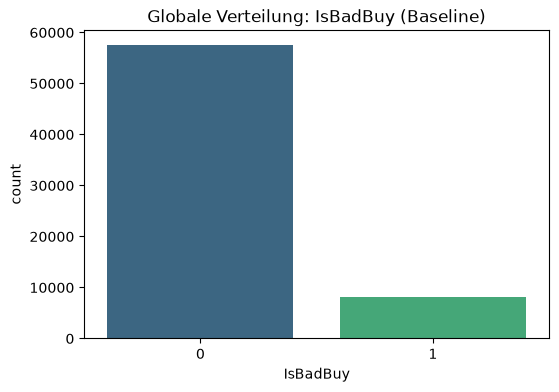

--- EXOTEN-AUDIT (Marken < 1% Anteil) ---
Anzahl seltener Marken: 14
Gesamtgewicht der Exoten: 3.84% des Datensatzes

Die 5 seltensten Marken (höchstes Risiko für Split-Inkonsistenz):


Make
VOLVO     33
ACURA     28
SUBARU    26
LEXUS     24
MINI      23
Name: count, dtype: int64

In [20]:
# SPLIT & TARGET DISTRIBUTION

# Check initial Target Distribution in raw data

target_stats = df_train['IsBadBuy'].value_counts()
target_percent = df_train['IsBadBuy'].value_counts(normalize=True) * 100

print(f"--- GLOBALE BASELINE (n={len(df_train)}) ---")
print(f"Klasse 0 (Gute Käufe): {target_stats[0]} ({target_percent[0]:.2f}%)")
print(f"Klasse 1 (Bad Buys):    {target_stats[1]} ({target_percent[1]:.2f}%)")

plt.figure(figsize=(6, 4))
sns.countplot(x='IsBadBuy', data=df_train, hue='IsBadBuy', palette='viridis', legend=False)
plt.title('Globale Verteilung: IsBadBuy (Baseline)')
plt.show()



# Wie viele Marken sind "Exoten" (< 1%)?
make_shares = df_train['Make'].value_counts(normalize=True) * 100
rare_makes = make_shares[make_shares < 1]

print(f"--- EXOTEN-AUDIT (Marken < 1% Anteil) ---")
print(f"Anzahl seltener Marken: {len(rare_makes)}")
print(f"Gesamtgewicht der Exoten: {rare_makes.sum():.2f}% des Datensatzes")

# Die 5 "gefährlichsten" Marken für den Split (weil am seltensten)
print("\nDie 5 seltensten Marken (höchstes Risiko für Split-Inkonsistenz):")
display(df_train['Make'].value_counts().tail(5))







~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
CLASSIFICATION DATA TRAIN TEST SPLIT (STRATIFIED)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Class Distribution: IsBadBuy
----------------------------------------


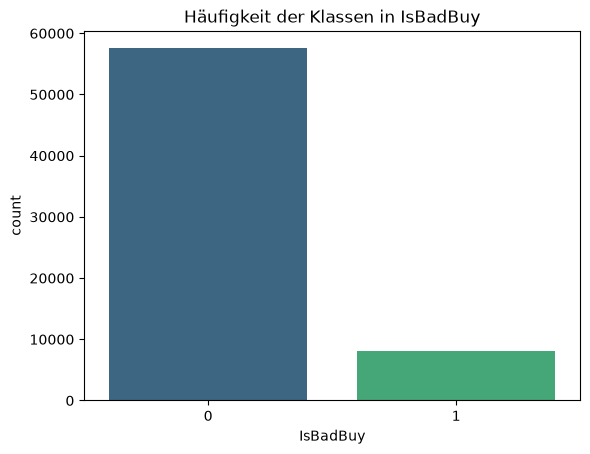


Split Shapes & Class Balance
----------------------------------------
Train (52496, 32) | Test (13124, 32)
BadBuy Rate Train: 12.35%
BadBuy Rate Test:  12.35%
----------------------------------------




,Original,Train-Set,Test-Set,Abweichung Train/Test %
Mittelwert,0.1200,0.1200,0.1200,0.0200
Median,0.0000,0.0000,0.0000,NaN
Std-Abw,0.3300,0.3300,0.3300,0.0100
Max,1.0000,1.0000,1.0000,0.0000
Min,0.0000,0.0000,0.0000,NaN


----------------------------------------



Schiefe
----------------------------------------


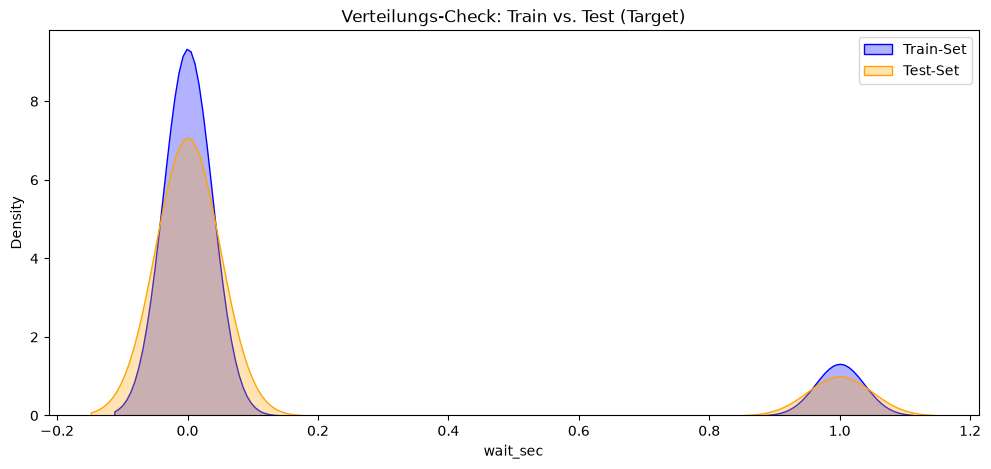


Note: Die Verteilung im Training-Set ist rechtsschief (Mean > Median).
----------------------------------------



Export to parquet
----------------------------------------
File:'../data/02_interim/features_train.parquet'
File:'../data/02_interim/features_test.parquet'
File:'../data/02_interim/target_train.parquet'
File:'../data/02_interim/target_test.parquet'
---
Split-Daten erfolgreich in '../data/02_interim/' gespeichert.
----------------------------------------




In [21]:
# SPLIT for Imbalanced Classification.

# 1. Den "Smarte" Classification Split ausführen
# Er nutzt intern 'stratify=target', um die 12,35% zu schützen
X_train, X_test, y_train, y_test = wg.classification_split_train_test(df_train, TARGET)

# 2. Speichern für die nächsten Phasen (Preprocessing/Model)
wg.save_split_data(X_train, X_test, y_train, y_test, DATA_PATH_OUTPUT)

---

# First EDA Insights

## EDA DataFrame

In [22]:
# DEFINE EDA DATAFRAME

df_eda = X_train.copy()
df_eda[TARGET] = y_train

display(df_eda)

,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,Transmission,...,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost,IsBadBuy
37348,2010-11-17,MANHEIM,2008,2,CHEVROLET,COBALT,LS,2D COUPE LS,BLACK,AUTO,...,10445.0000,NaN,NaN,19638,33809,FL,6850.0000,0,728.0000,0
38894,2010-03-16,MANHEIM,2005,5,CHEVROLET,TRAILBLAZER 2WD 6C,LS,4D SUV 4.2L,SILVER,AUTO,...,12994.0000,NaN,NaN,19638,34761,FL,8085.0000,0,1341.0000,0
56871,2010-01-27,MANHEIM,2006,4,CHRYSLER,PT CRUISER,Tou,4D SEDAN,SILVER,AUTO,...,9545.0000,NaN,NaN,20833,78219,TX,5825.0000,0,1215.0000,0
44648,2010-07-06,MANHEIM,2003,7,CHEVROLET,TRAILBLAZER 4WD 6C,LS,4D SUV 4.2L LS,BROWN,AUTO,...,10535.0000,NaN,NaN,20207,77041,TX,7400.0000,0,2651.0000,0
11413,2009-01-12,MANHEIM,2005,4,JEEP,LIBERTY 4WD V6 3.7L,Spo,4D SUV,BLUE,AUTO,...,10830.0000,NaN,NaN,18880,27542,NC,6600.0000,0,754.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8584,2010-09-23,MANHEIM,2005,5,CHEVROLET,COBALT,Bas,4D SEDAN,BLUE,AUTO,...,8917.0000,NaN,NaN,23657,92337,CA,5355.0000,0,803.0000,0
29724,2009-02-09,MANHEIM,2005,4,MERCURY,MARINER 4WD V6 3.0L,Bas,4D SUV 3.0L,WHITE,AUTO,...,9516.0000,NaN,NaN,21973,27542,NC,7400.0000,0,1503.0000,0
51247,2009-05-20,OTHER,2006,3,PONTIAC,GRAND PRIX 3.8L V6 S,Bas,4D SEDAN,OTHER,AUTO,...,9733.0000,NaN,NaN,19638,35004,AL,7600.0000,0,1703.0000,0
63120,2010-07-20,MANHEIM,2002,8,FORD,EXPEDITION 4WD V8,Edd,4D SUV 5.4L EDDIE BAUER,BLACK,AUTO,...,9396.0000,NaN,NaN,52492,28625,NC,8910.0000,0,1930.0000,0


## Basic Statistical Data

#### Description

Die Funktion **`inspect_data`** fungiert als zentraler Orchestrator, der verschiedene Analyse-Module aufruft, um einen umfassenden Statusbericht eines DataFrames zu erstellen.

#### Result

In [23]:
# BASIC DATA INSPECTION

wg.inspect_data(df_eda, name='Initial EDA-DataFrame')




~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
DATA REPORT: INITIAL EDA-DATAFRAME
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Dimensions & Quality
----------------------------------------
Zeilen:      52496
Spalten:     33
Duplikate:   0 (0.0%)
Spalten NAs:
Trim                                  1683
SubModel                                 4
Color                                    4
Transmission                             5
WheelTypeID                           2302
WheelType                             2304
Nationality                              4
Size                                     4
TopThreeAmericanName                     4
MMRAcquisitionAuctionAveragePrice       12
MMRAcquisitionAuctionCleanPrice         12
MMRAcquisitionRetailAveragePrice        12
MMRAcquisitonRetailCleanPrice           12
MMRCurrentAuctionAveragePrice          226
MMRCurrentAuctionCleanPrice            226
MMRCurrentRetailAveragePrice           226
MMRCurrentRetailCleanPrice             226
PRIMEUNIT       

,VehYear,VehicleAge,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,VehBCost,IsOnlineSale,WarrantyCost,IsBadBuy
count,52496.0000,52496.0000,52496.0000,52484.0000,52484.0000,52484.0000,52484.0000,52270.0000,52270.0000,52270.0000,52270.0000,52452.0000,52496.0000,52496.0000,52496.0000
mean,2005.3400,4.1800,71497.3500,6124.9400,7369.5100,8496.0700,9850.3700,6130.6900,7389.0300,8775.0500,10144.1300,6726.4100,0.0300,1278.2500,0.1200
std,1.7300,1.7100,14577.0200,2449.4200,2707.9300,3145.6600,3373.7900,2424.7700,2674.7600,3081.1100,3300.1100,1759.5500,0.1600,598.5700,0.3300
min,2001.0000,0.0000,5368.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1400.0000,0.0000,462.0000,0.0000
25%,2004.0000,3.0000,61793.5000,4273.0000,5406.7500,6275.7500,7490.0000,4279.0000,5417.0000,6543.2500,7783.2500,5430.0000,0.0000,837.0000,0.0000
50%,2005.0000,4.0000,73371.0000,6098.0000,7307.0000,8447.0000,9794.0000,6067.0000,7316.0000,8730.0000,10103.0000,6700.0000,0.0000,1169.0000,0.0000
75%,2007.0000,5.0000,82457.0000,7766.0000,9024.2500,10661.0000,12111.0000,7737.0000,9015.7500,10913.0000,12312.7500,7900.0000,0.0000,1623.0000,0.0000
max,2010.0000,9.0000,115717.0000,35722.0000,36859.0000,39080.0000,41482.0000,35722.0000,36859.0000,39080.0000,41062.0000,38785.0000,1.0000,7498.0000,1.0000



EDA ToDos
----------------------------------------
[CHECKS]
  - Fehlwerte in Spalten ['Trim', 'SubModel', 'Color', 'Transmission', 'WheelTypeID', 'WheelType', 'Nationality', 'Size', 'TopThreeAmericanName', 'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 'PRIMEUNIT', 'AUCGUART', 'VehBCost']. Imputation prüfen.
  - Hohe Fehlwerte (>10%) in Spalten ['PRIMEUNIT', 'AUCGUART']. Imputation prüfen.

[VISUALISIERUNGS]
  - Boxplot für 'VehicleAge' (448 q1/q3 +/- 1.5)
  - Boxplot für 'VehOdo' (227 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitionAuctionAveragePrice' (343 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitionAuctionCleanPrice' (568 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitionRetailAveragePrice' (198 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitonRetailCleanPrice' (860 q1/q3 +

## Data Fast Quality Check

* Hohe Fehlzahlen bei PRIMEUNIT, AUCGUART
* Wenige Fehlzahlen bei Trim, WheelTypeID, WheelType

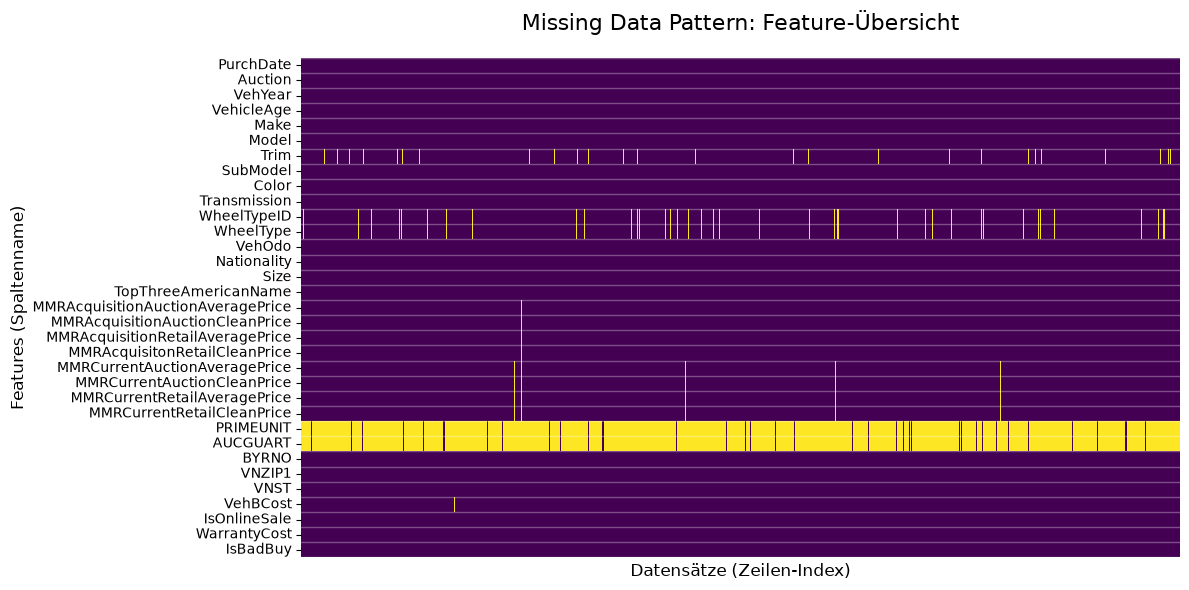

In [24]:

plt.figure(figsize=(12, 6))

# Heatmap erstellen
# yticklabels=True zeigt alle Feature-Namen an
ax = sns.heatmap(df_eda.isnull().T, cbar=False, cmap='viridis', xticklabels=False, yticklabels=True)

# Horizontale Linien für die Zeilentrennung hinzufügen
# Wir ziehen nach jedem Feature eine feine graue Linie
for i in range(df_eda.shape[1] + 1):
    ax.axhline(i, color='white', lw=1, alpha=0.3)

plt.title('Missing Data Pattern: Feature-Übersicht', fontsize=16, pad=20)
plt.xlabel('Datensätze (Zeilen-Index)', fontsize=12)
plt.ylabel('Features (Spaltenname)', fontsize=12)

# Layout optimieren, damit die Namen links nicht abgeschnitten werden
plt.tight_layout()
plt.show()

/var/folders/jh/b553h44j08x_jr8xwh9jbc5r0000gn/T/ipykernel_3081/1097027127.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='IsBadBuy', y='WarrantyCost', palette='Set2')


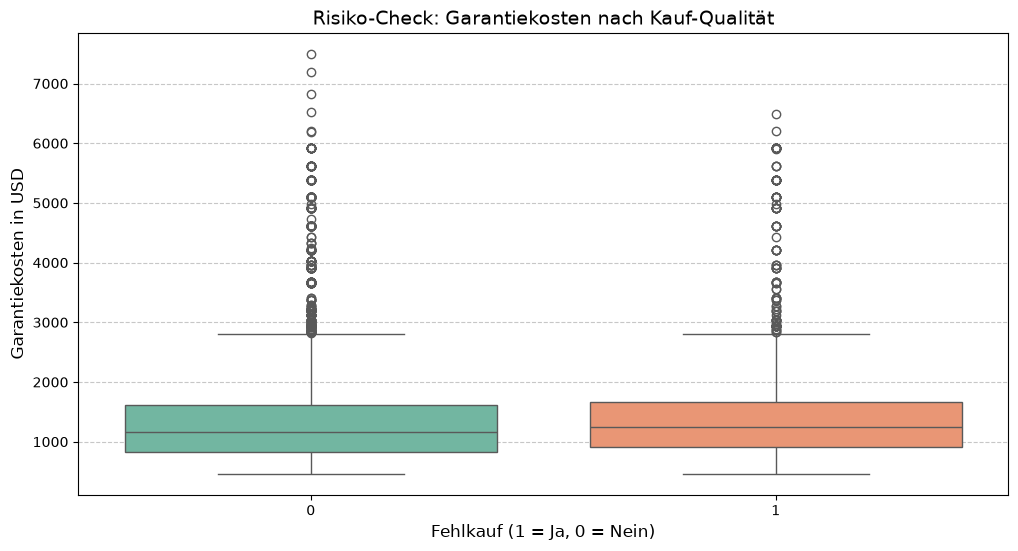

In [25]:
# Garantiekosten (WarrantyCost) für BadBuys vs. GoodBuys im Vergleich
plt.figure(figsize=(12, 6))

# Wir vergleichen die Garantiekosten (WarrantyCost) direkt für BadBuys vs. GoodBuys
sns.boxplot(data=df_eda, x='IsBadBuy', y='WarrantyCost', palette='Set2')

plt.title('Risiko-Check: Garantiekosten nach Kauf-Qualität', fontsize=14)
plt.xlabel('Fehlkauf (1 = Ja, 0 = Nein)', fontsize=12)
plt.ylabel('Garantiekosten in USD', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Data Completeness (Duplicates, Missing Values)

* Keine Duplikate
  
* NaNs in folgenden Spalten sind zu überprüfen:
    * Trim: 1655
    * SubModel: 6
    * Color: 6
    * Transmission: 7
    * WheelTypeID: 2303
    * WheelType: 2307
    * Nationality: 2
    * Size: 2
    * TopThreeAmericanName: 2
    * MMRAcquisitionAuctionAveragePrice: 12
    * MMRAcquisitionAuctionCleanPrice: 12
    * MMRAcquisitionRetailAveragePrice: 12
    * MMRAcquisitonRetailCleanPrice: 12
    * MMRCurrentAuctionAveragePrice: 238
    * MMRCurrentAuctionCleanPrice: 238
    * MMRCurrentRetailAveragePrice: 238
    * MMRCurrentRetailCleanPrice: 238
    * PRIMEUNIT: 50025
    * AUCGUART: 50025
    * VehBCost: 42

#### Kategoriale Features


NaN-Prüfung kategoriale Features:

| Feature | Missing (Abs) | Missing (%) | Status |
| :--- | :--- | :--- | :--- |
| TopThreeAmericanName | 2 | 0,00 % | Imputation nötig NaN => UNKNOWN |
| Nationality | 2 | 0,00 % | Imputation nötig NaN => UNKNOWN |
| Size | 2 | 0,00 % | Imputation nötig NaN => UNKNOWN |
| SubModel | 6 | 0,01 % | Imputation nötig NaN => UNKNOWN |
| Color | 6 | 0,01 % | Imputation nötig NaN => UNKNOWN |
| Transmission | 7 | 0,01 % | Imputation nötig NaN => UNKNOWN |
| Trim | 1655 | 3,15 % | Imputation nötig NaN => UNKNOWN |
| WheelTypeID | 2303 | 4,39 % | Imputation nötig NaN => UNKNOWN |
| WheelType | 2307 | 4,39 % | Imputation nötig NaN => UNKNOWN |
| PRIMEUNIT | 50025 | 95,29 % | ‼ Hoher Verlust,  NaN => UNKNOWN |
| AUCGUART | 50025 | 95,29 % | ‼ Hoher Verlust,  NaN => UNKNOWN |

* Bei Spalten mit wenigen fehlenden Daten, unter 1 %, ist UNKNOWN unbedenklich.
* Bei Trim könnte man die häufigste Ausstattung in der Model-Gruppe testen — hängt vermutlich mit den MMR-Werten zusammen.
* Auch bei AUCGUART UNKNOWN statt YELLOW, weil es sonst in zukünftigen Datensätzen mit richtigen YELLOWs deutlich verzerren würde.

#### Numerische Features


NaN-Prüfung numerische Features:

| Feature | Missing (Abs) | Missing (%) | Empfohlene Strategie |
| :--- | :--- | :--- | :--- |
| MMRAcquisitionAuctionAveragePrice | 12 | 0,02 % | Median (gruppiert nach Model/Year) |
| MMRAcquisitionAuctionCleanPrice | 12 | 0,02 % | Median (gruppiert nach Model/Year) |
| MMRAcquisitionRetailAveragePrice | 12 | 0,02 % | Median (gruppiert nach Model/Year) |
| MMRAcquisitonRetailCleanPrice | 12 | 0,02 % | Median (gruppiert nach Model/Year) |
| MMRCurrentAuctionAveragePrice | 238 | 0,45 % | Median (gruppiert nach Model/Year) |
| MMRCurrentAuctionCleanPrice | 238 | 0,45 % | Median (gruppiert nach Model/Year) |
| MMRCurrentRetailAveragePrice | 238 | 0,45 % | Median (gruppiert nach Model/Year) |
| MMRCurrentRetailCleanPrice | 238 | 0,45 % | Median (gruppiert nach Model/Year) |
| VehBCost | 42 | 0,08 % | Median |


**Wichtige Features**
* MMR-Werte (Manheim Market Report) sind die Richtwerte im Automobilhandel und bilden eine Preismatrix ab. Für die Vorhersage besonders wichtig, deshalb versuchen wir diese gezielt sauber aufzubereiten.
    * Marktwert: Kauf vs. Aktuell
    * Marktsegment: Großhandel vs. Einzelhandel
    * Zustand: Durchschnitt vs. gepflegt

**Zero-Inflation**
* Es sind nicht nur NaN in der Statistik, sondern auch viele 0 — das ist nicht plausibel und sollte deshalb besonders behandelt werden.
    * Die Nullen sollten in NaNs gewandelt werden, damit sie die Statistik nicht verfälschen.
    * NaNs werden anschließend durch einen gruppierten Median ersetzt, damit die Segmentierung durch den globalen Median nicht zerstört wird.

In [26]:
# Übersicht der nummerischen Fehlwerte mit NaN und 0

num_cols = df_eda.select_dtypes(include=['number']).columns
num_cols_missing = df_eda[num_cols].columns[df_eda[num_cols].isna().any()].tolist()

num_cols_stats_check = df_eda[num_cols_missing].describe().T
num_cols_stats_check['count_zeros'] = (df_eda[num_cols_missing] == 0).sum()
num_cols_stats_check['count_nan'] = df_eda[num_cols_missing].isna().sum()
num_cols_stats_check['total_invalid'] = num_cols_stats_check['count_zeros'] + num_cols_stats_check['count_nan']
num_cols_stats_check['invalid_pct'] = (num_cols_stats_check['total_invalid'] / len(df_eda) * 100).round(2)
display(num_cols_stats_check.sort_values(by='total_invalid', ascending=False))

,count,mean,std,min,25%,50%,75%,max,count_zeros,count_nan,total_invalid,invalid_pct
MMRAcquisitionAuctionAveragePrice,52484.0000,6124.9403,2449.4209,0.0000,4273.0000,6098.0000,7766.0000,35722.0000,586,12,598,1.1400
MMRAcquisitionRetailAveragePrice,52484.0000,8496.0746,3145.6643,0.0000,6275.7500,8447.0000,10661.0000,39080.0000,586,12,598,1.1400
MMRAcquisitonRetailCleanPrice,52484.0000,9850.3684,3373.7908,0.0000,7490.0000,9794.0000,12111.0000,41482.0000,586,12,598,1.1400
MMRCurrentAuctionAveragePrice,52270.0000,6130.6911,2424.7694,0.0000,4279.0000,6067.0000,7737.0000,35722.0000,351,226,577,1.1000
MMRCurrentRetailAveragePrice,52270.0000,8775.0458,3081.1106,0.0000,6543.2500,8730.0000,10913.0000,39080.0000,351,226,577,1.1000
MMRCurrentRetailCleanPrice,52270.0000,10144.1342,3300.1123,0.0000,7783.2500,10103.0000,12312.7500,41062.0000,351,226,577,1.1000
MMRAcquisitionAuctionCleanPrice,52484.0000,7369.5145,2707.9324,0.0000,5406.7500,7307.0000,9024.2500,36859.0000,488,12,500,0.9500
MMRCurrentAuctionCleanPrice,52270.0000,7389.0305,2674.7550,0.0000,5417.0000,7316.0000,9015.7500,36859.0000,259,226,485,0.9200
VehBCost,52452.0000,6726.4113,1759.5544,1400.0000,5430.0000,6700.0000,7900.0000,38785.0000,0,44,44,0.0800


In [27]:
# PROTOTYPE FUNKTION FÜR PROCESSING...
# ==============================================================================
# KAPITEL: COMPLETENESS -> FINALE ERZEUGUNG VON df_impute
# ==============================================================================

# 1. INITIALE KOPIE
df_impute = df_eda.copy()

# 2. ZERO-INFLATION BEREINIGEN (MMR-Preise)
mmr_cols = [col for col in df_impute.columns if 'MMR' in col]
df_impute[mmr_cols] = df_impute[mmr_cols].replace(0, np.nan)

# 3. HIERARCHISCHE IMPUTATION (Die schicke Logik)
print(f"🔍 Starte hierarchische Imputation für {len(mmr_cols)} Preis-Features...")

levels = [
    ['Model', 'VehYear'],      # Level 1: Sehr spezifisch
    ['Make', 'VehYear'],       # Level 2: Marke/Jahr
    ['VehicleAge'],            # Level 3: Alter (Haupttreiber)
    ['VehYear']                # Level 4: Nur Jahr (letzter Anker)
]

for i, group_cols in enumerate(levels, 1):
    for col in mmr_cols:
        mask = df_impute[col].isna()
        if mask.any():
            # Gruppierter Median berechnen
            group_series = df_impute.groupby(group_cols, observed=False)[col]
            group_medians = group_series.transform('median')
            # Nur die Lücken füllen, die auf diesem Level einen Wert finden
            df_impute.loc[mask, col] = group_medians[mask]
    
    current_nans = df_impute[mmr_cols].isna().sum().sum()
    print(f"Level {i} ({', '.join(group_cols)}): {current_nans} NaNs verbleibend")

# Letzter Fallback für absolute Exoten (globaler Median)
df_impute[mmr_cols] = df_impute[mmr_cols].fillna(df_impute[mmr_cols].median())
df_impute['VehBCost'] = df_impute['VehBCost'].fillna(df_impute['VehBCost'].median())

# 4. KATEGORIALE IMPUTATION
cat_cols = df_impute.select_dtypes(include=['category', 'object']).columns
for col in cat_cols:
    if col == 'Transmission':
        df_impute[col] = df_impute[col].astype(str).str.upper().replace('NAN', 'UNKNOWN').astype('category')
    else:
        df_impute[col] = df_impute[col].astype(object).fillna('UNKNOWN').astype('category')

# 5. AUFRÄUMEN
if 'WheelTypeID' in df_impute.columns:
    df_impute = df_impute.drop(columns=['WheelTypeID'])


# Den Report auf den aktuellen Stand abfeuern
wg.inspect_data(df_impute, name='Completeness Impute-DataFrame')

🔍 Starte hierarchische Imputation für 8 Preis-Features...
Level 1 (Model, VehYear): 432 NaNs verbleibend
Level 2 (Make, VehYear): 4 NaNs verbleibend
Level 3 (VehicleAge): 0 NaNs verbleibend
Level 4 (VehYear): 0 NaNs verbleibend



~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
DATA REPORT: COMPLETENESS IMPUTE-DATAFRAME
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Dimensions & Quality
----------------------------------------
Zeilen:      52496
Spalten:     32
Duplikate:   0 (0.0%)
Spalten NAs:
Transmission    5
dtype: int64

Structure & NaN-Values
----------------------------------------
                                           Dtype  Nulls  Null %  Unique
PurchDate                          datetime64[s]      0  0.0000     515
Auction                                 category      0  0.0000       3
VehYear                                    int16      0  0.0000      10
VehicleAge                                  int8      0  0.0000      10
Make                                    category      0

,VehYear,VehicleAge,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,VehBCost,IsOnlineSale,WarrantyCost,IsBadBuy
count,52496.0000,52496.0000,52496.0000,52496.0000,52496.0000,52496.0000,52496.0000,52496.0000,52496.0000,52496.0000,52496.0000,52496.0000,52496.0000,52496.0000,52496.0000
mean,2005.3400,4.1800,71497.3500,6193.9500,7435.7700,8594.9100,9965.0500,6173.1900,7421.5000,8828.5400,10206.5700,6726.3900,0.0300,1278.2500,0.1200
std,1.7300,1.7100,14577.0200,2371.5100,2628.4800,3024.7700,3220.1200,2377.6300,2630.8700,3003.1400,3200.9600,1758.8200,0.1600,598.5700,0.3300
min,2001.0000,0.0000,5368.0000,884.0000,1.0000,1455.0000,1662.0000,369.0000,1.0000,899.0000,1034.0000,1400.0000,0.0000,462.0000,0.0000
25%,2004.0000,3.0000,61793.5000,4342.0000,5468.0000,6374.7500,7574.0000,4318.0000,5446.7500,6589.0000,7838.0000,5435.0000,0.0000,837.0000,0.0000
50%,2005.0000,4.0000,73371.0000,6144.0000,7352.5000,8481.0000,9838.0000,6096.0000,7332.0000,8753.0000,10111.5000,6700.0000,0.0000,1169.0000,0.0000
75%,2007.0000,5.0000,82457.0000,7779.0000,9038.0000,10686.0000,12138.0000,7749.0000,9018.0000,10920.0000,12322.0000,7900.0000,0.0000,1623.0000,0.0000
max,2010.0000,9.0000,115717.0000,35722.0000,36859.0000,39080.0000,41482.0000,35722.0000,36859.0000,39080.0000,41062.0000,38785.0000,1.0000,7498.0000,1.0000



EDA ToDos
----------------------------------------
[CHECKS]
  - Fehlwerte in Spalten ['Transmission']. Imputation prüfen.

[VISUALISIERUNGS]
  - Boxplot für 'VehicleAge' (448 q1/q3 +/- 1.5)
  - Boxplot für 'VehOdo' (227 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitionAuctionAveragePrice' (366 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitionAuctionCleanPrice' (720 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitionRetailAveragePrice' (218 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitonRetailCleanPrice' (284 q1/q3 +/- 1.5)
  - Boxplot für 'MMRCurrentAuctionAveragePrice' (396 q1/q3 +/- 1.5)
  - Boxplot für 'MMRCurrentAuctionCleanPrice' (704 q1/q3 +/- 1.5)
  - Boxplot für 'MMRCurrentRetailAveragePrice' (200 q1/q3 +/- 1.5)
  - Boxplot für 'MMRCurrentRetailCleanPrice' (298 q1/q3 +/- 1.5)
  - Boxplot für 'VehBCost' (132 q1/q3 +/- 1.5)
  - Boxplot für 'IsOnlineSale' (1342 q1/q3 +/- 1.5)
  - Boxplot für 'WarrantyCost' (603 q1/q3 +/- 1.5)
  - Boxplot für 'IsBadBuy' (6483 q1/q3 +/- 1.5)
  - Countplot für '

## Export für 01a

In [28]:
df_eda.to_parquet(f'{DATA_PATH_OUTPUT}df_eda.parquet')
df_impute.to_parquet(f'{DATA_PATH_OUTPUT}df_impute.parquet')

print(f"df_eda    {df_eda.shape}    -> {DATA_PATH_OUTPUT}df_eda.parquet")
print(f"df_impute {df_impute.shape} -> {DATA_PATH_OUTPUT}df_impute.parquet")

df_eda    (52496, 33)    -> ../data/02_interim/df_eda.parquet
df_impute (52496, 32) -> ../data/02_interim/df_impute.parquet
